In [14]:
"""
Макропрогнозирование (Эконометрика против ML)
В рамках этого практического модуля мы решаем классическую задачу макроэкономического 
прогнозирования: 
предсказание будущих темпов роста экономики (ВВП) на горизонте одного года (4 квартала).

Главная цель этого задания — на практике столкнуть лбами два принципиально разных 
аналитических подхода:

Классическую эконометрику, к которой вы привыкли (модели векторной авторегрессии — VAR), где упор делается на 
совместную динамику и статистические свойства временных рядов.
Машинное обучение (ансамблевые модели: Random Forest и Gradient Boosting), 
где алгоритм самостоятельно ищет 
нелинейные зависимости и сложные паттерны в данных для максимизации точности прогноза.
Помимо самого моделирования, мы пройдем весь путь инженера данных (Data Engineer), 
максимально приближенный к реальным 
задачам в банках и хедж-фондах: от автоматического сбора сырых данных по API 
до их очистки и сведения в единую структуру с помощью SQL.

Какие данные мы используем?
Для построения прогноза мы будем использовать открытые данные Федерального 
резервного банка Сент-Луиса (база FRED). 
Это один из самых надежных и популярных источников макростатистики в мире.

Мы возьмем четыре ключевых индикатора, которые описывают разные аспекты экономики, 
но при этом имеют разную частотность публикации,
что создает типичную проблему для аналитика:

Реальный ВВП (GDP) — наш целевой показатель. Отражает общий объем экономики. 
Частотность: Квартальная.
Индекс потребительских цен (CPIAUCSL) — ключевая мера инфляции. Частотность: Месячная.
Уровень безработицы (UNRATE) — индикатор состояния рынка труда. Частотность: Месячная.
Доходность 10-летних казначейских облигаций США (DGS10) — индикатор 
стоимости денег и ожиданий инвесторов 
относительно будущих процентных ставок и инфляции. Частотность: Дневная.

Что именно будет происходить в коде (Краткий план действий):
Сбор и хранение: Сначала мы программно скачаем ряды разной частотности напрямую 
с серверов FRED и загрузим их в 
базу данных MySQL в "сыром" виде. На этом этапе данные будут полны пропусков 
(например, значение ВВП будет публиковаться 
лишь раз в квартал, а доходность облигаций — каждый день).
SQL-агрегация: С помощью SQL-запроса мы решим проблему частотности 
(Mixed-Frequency Data). Мы приведем все данные к единой 
квартальной сетке: ВВП возьмем по факту публикации, а дневные и месячные 
показатели (ставки, инфляцию, безработицу) усредним за соответствующий квартал.
Эконометрический этап: Мы проверим данные на стационарность, перейдем от абсолютных значений к темпам прироста и 
первым разностям (чтобы избежать ложной регрессии), а затем построим модель VAR(p) для прогнозирования на 4 квартала вперед.
Feature Engineering для ML: Поскольку деревья решений не понимают концепцию "времени", мы вручную создадим для них 
предикторы: сдвинем ряды в прошлое (добавим лаги) и посчитаем скользящую волатильность рынка. Также мы применим 
подход Direct Forecasting — сдвинем сам целевой ВВП на 4 квартала назад, чтобы модель училась предсказывать отдаленное будущее напрямую.
Обучение и оценка: Мы обучим Случайный лес и Градиентный бустинг, строго разделив выборку на обучающую (до 2019 года) 
и тестовую (с 2019 года). В конце мы сравним ошибку прогноза (RMSE и MAE) у эконометрики и ML-алгоритмов, а также посмотрим 
на график важности признаков, чтобы понять, на какие именно индикаторы опирался искусственный интеллект при принятии решений.
"""

''

In [3]:
!pip3 install fredapi

In [38]:
!pip3 install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 561.0 kB/s eta 0:00:00a 0:00:02


In [233]:
import pandas as pd
from fredapi import Fred
from sqlalchemy import create_engine, text

In [235]:
FRED_API_KEY = 'b51ee61dc80dc997c3d488c0ef3d630a'

TICKERS = {
    'gdp': 'GDP',
    'cpi': 'CPIAUCSL',
    'unrate': 'UNRATE',
    'dgs10': 'DGS10'
}

fred = Fred(api_key=FRED_API_KEY)
df_macro = pd.DataFrame()
for col_name, ticker in TICKERS.items():
    df_macro[col_name] = fred.get_series(ticker)

df_macro.reset_index(inplace=True)
df_macro.rename(columns={'index': 'date'}, inplace=True)
df_macro.head()

,date,gdp,cpi,unrate,dgs10
0,1946-01-01,NaN,NaN,NaN,NaN
1,1946-04-01,NaN,NaN,NaN,NaN
2,1946-07-01,NaN,NaN,NaN,NaN
3,1946-10-01,NaN,NaN,NaN,NaN
4,1947-01-01,243.164,21.48,NaN,NaN


In [26]:
# df_macro['date'] = df_macro['date'].dt.date
df_macro.head()

,date,gdp,cpi,unrate,dgs10
0,1946-01-01,NaN,NaN,NaN,NaN
1,1946-04-01,NaN,NaN,NaN,NaN
2,1946-07-01,NaN,NaN,NaN,NaN
3,1946-10-01,NaN,NaN,NaN,NaN
4,1947-01-01,243.164,21.48,NaN,NaN


In [44]:

# TODO 1.1: Заполните параметры подключения
DB_USER = 'root'
DB_PASSWORD = 'Dfyzdfyz1993!'
DB_HOST = '127.0.0.1'
DB_NAME = 'macro_db'



# TODO 1.2: Отфильтруйте DataFrame, оставив только наблюдения начиная с 1 января 1990 года
df_macro = df_macro[df_macro['date'] >= pd.Timestamp('1990-01-01')]

conn_string = f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
engine = create_engine(conn_string)

# TODO 1.3: Вызовите метод записи в SQL. 
# Используйте имя таблицы 'raw_macro_data'. 
# Настройте параметр if_exists так, чтобы таблица перезаписывалась, и отключите экспорт индекса.
# <ВАШ_КОД>
df_macro.head()

,date,gdp,cpi,unrate,dgs10
176,1990-01-01,5872.701,127.5,5.4,NaN
177,1990-04-01,5960.028,128.9,5.4,NaN
178,1990-07-01,6015.116,130.5,5.5,NaN
179,1990-10-01,6004.733,133.4,5.9,8.71
180,1991-01-01,6035.178,134.7,6.4,NaN


In [48]:
with engine.connect() as conn:
    # conn.execute("commit")  # Завершаем текущую транзакцию
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}"))
    print(f"База данных {DB_NAME} создана или уже существует")

База данных macro_db создана или уже существует


In [50]:
conn_string = f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
engine = create_engine(conn_string)

df_macro.to_sql(
    name='raw_macro_data',           # имя таблицы в БД
    con=engine,
    if_exists='replace',             # 'fail', 'replace', 'append'
    index=False,                   # не записывать индекс DataFrame
    method='multi'                 # ускоряет вставку больших объёмов данных
)

144

In [53]:
!pip3 install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 625.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [89]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.hypothesis_test_results import NormalityTestResults

# TODO 2.1: Допишите SQL-запрос. 
# Нам нужно агрегировать данные по годам и кварталам.
# ВВП (gdp) нужно взять как максимальное значение (MAX) за квартал.
# Остальные переменные (cpi, unrate, dgs10) - как среднее (AVG).
query = """
SELECT 
    CONCAT(b.year, '-', LPAD((b.quarter-1)*3 + 1, 2, '0'), '-01') AS quarter_date,
    max(b.gdp) AS gdp,
    avg(b.cpi) AS cpi,
    avg(b.unrate) AS unrate
FROM (
    select
        a.*,
        YEAR(a.date) as year,
        QUARTER(a.date) as quarter
    from raw_macro_data as a
    ) as b
GROUP BY b.year, b.quarter
ORDER BY quarter_date;
"""

df_quarterly = pd.read_sql(query, con=engine)
df_quarterly['quarter_date'] = pd.to_datetime(df_quarterly['quarter_date'])
df_quarterly.set_index('quarter_date', inplace=True)
df_quarterly.dropna(inplace=True) 

# TODO 2.2: Переведите ряды в стационарный вид.
# Для ВВП (gdp) и инфляции (cpi) рассчитайте темп прироста: разность логарифмов, 
# умноженная на 100.
# Для ставок (unrate, dgs10) возьмите обычную первую разность (метод .diff() в pandas).
df_diff = pd.DataFrame()
df_diff['gdp_growth'] = 100*(np.log(df_quarterly['gdp']) - np.log(df_quarterly['gdp'].shift(1)))
df_diff['cpi_inflation'] = 100*(np.log(df_quarterly['cpi']) - np.log(df_quarterly['cpi'].shift(1)))
df_diff.dropna(inplace=True)
df_diff['unrate_diff'] = np.diff(df_quarterly['unrate'])
# df_diff['dgs10_diff'] = # <ВАШ_КОД>

# TODO 2.3: Обучите модель VAR.
# Инициализируйте модель, передав ей датафрейм df_diff.
# Используйте метод .fit() с выбором оптимального лага по критерию AIC (максимальный лаг задайте равным 4).
df_diff_train = df_diff.iloc[:int(len(df_diff)*0.8)-1]
df_diff_test = df_diff.iloc[int(len(df_diff)*0.8):]
model_var = VAR(df_diff_train)
results_var = model_var.fit(ic="aic")
print("Оптимальный порядок VAR(p):", results_var.k_ar)
print(results_var.summary())
# print(NormalityTestResults(results_var.resid['gdp_growth'].values))
# # TODO 2.4: Сделайте прогноз на 4 квартала вперед, используя метод .forecast()
# forecast_var = # <ВАШ_КОД>


Оптимальный порядок VAR(p): 4
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 20, Apr, 2026
Time:                     16:04:12
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -4.51814
Nobs:                     108.000    HQIC:                  -5.09398
Log likelihood:          -124.455    FPE:                 0.00415612
AIC:                     -5.48669    Det(Omega_mle):      0.00295531
--------------------------------------------------------------------
Results for equation gdp_growth
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.501905         0.196935            2.549           0.011
L1.gdp_growth            0.305877         0.105339            2.904           0.004
L1.cpi_inflat

/opt/homebrew/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [94]:
df_diff_test.head()

,gdp_growth,cpi_inflation,unrate_diff
quarter_date,,,
2018-07-01,1.052788,0.393666,-0.2
2018-10-01,0.571175,0.618273,0.0
2019-01-01,0.921898,-0.083509,0.2
2019-04-01,1.347191,1.052405,-0.3
2019-07-01,1.480868,0.222685,0.0


In [96]:
res = results_var.forecast(df_diff_test.values[results_var.k_ar:], len(df_diff_test))

In [102]:
res.T[0]

array([1.34325158, 1.47425539, 1.4080732 , 1.36922908, 1.29071816,
       1.20668301, 1.18280417, 1.19447565, 1.18160364, 1.183267  ,
       1.17568864, 1.16848008, 1.16569988, 1.16125891, 1.15930321,
       1.15882347, 1.15791614, 1.15779316, 1.15742422, 1.15699009,
       1.15682022, 1.15660454, 1.15650977, 1.15649387, 1.15646489,
       1.15647543, 1.15648095, 1.1564813 , 1.1564924 ])

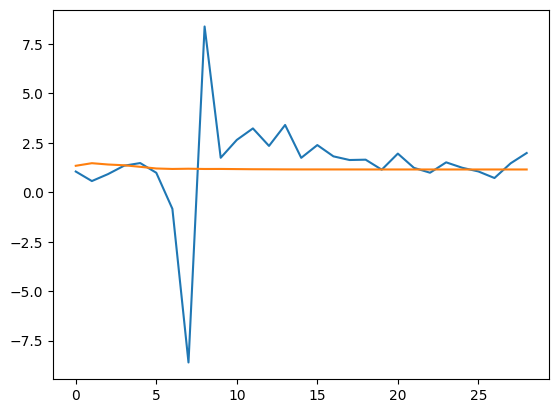

In [120]:
from matplotlib import pyplot as plt

plt.plot(df_diff_test['gdp_growth'].values)
plt.plot(res.T[0])

In [74]:
np.log(df_quarterly['gdp']) - np.log(df_quarterly['gdp'].shift(1))

quarter_date
1990-01-01         NaN
1990-04-01    0.014761
1990-07-01    0.009200
1990-10-01   -0.001728
1991-01-01    0.005057
                ...   
2024-07-01    0.012432
2024-10-01    0.010567
2025-01-01    0.007247
2025-04-01    0.014659
2025-07-01    0.019886
Name: gdp, Length: 143, dtype: float64

/opt/homebrew/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


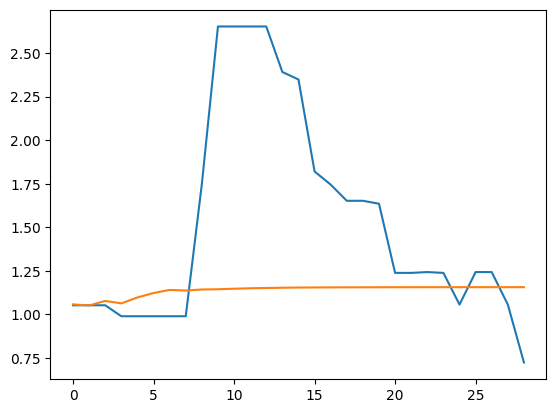

In [136]:
from scipy.signal import medfilt

df_diff_filt = df_diff.copy()
df_diff_filt['gdp_growth'] = medfilt(df_diff['gdp_growth'].values, kernel_size=5)
df_diff_filt['cpi_inflation'] = medfilt(df_diff['cpi_inflation'].values, kernel_size=5)
df_diff_filt['unrate_diff'] = medfilt(df_diff['unrate_diff'].values, kernel_size=5)
# plt.plot(df_diff['gdp_growth'].values)
# plt.plot(filtered)

df_diff_train = df_diff_filt.iloc[:int(len(df_diff)*0.8)-1]
df_diff_test = df_diff_filt.iloc[int(len(df_diff)*0.8):]
model_var = VAR(df_diff_train)
res = results_var.forecast(df_diff_test.values[results_var.k_ar:], len(df_diff_test))
plt.plot(df_diff_test['gdp_growth'].values)
plt.plot(res.T[0])

/opt/homebrew/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


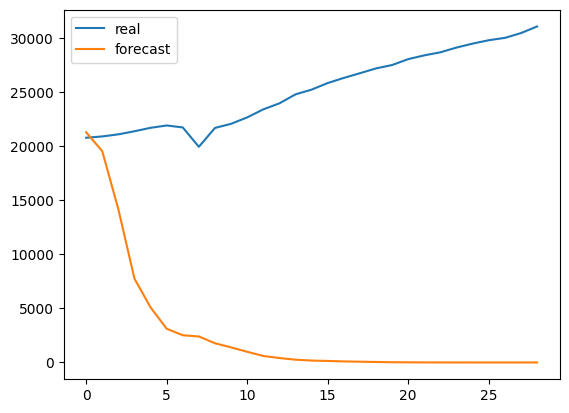

In [134]:
df_diff_filt = df_quarterly.copy()
# df_diff_filt['gdp'] = medfilt(df_quarterly['gdp'].values, kernel_size=7)
# df_diff_filt['cpi'] = medfilt(df_quarterly['cpi'].values, kernel_size=7)
# df_diff_filt['unrate'] = medfilt(df_quarterly['unrate'].values, kernel_size=7)
# plt.plot(df_diff['gdp_growth'].values)
# plt.plot(filtered)

df_diff_train = df_diff_filt.iloc[:int(len(df_quarterly)*0.8)-1]
df_diff_test = df_diff_filt.iloc[int(len(df_quarterly)*0.8):]
model_var = VAR(df_diff_train)
res = results_var.forecast(df_diff_test.values[results_var.k_ar:], len(df_diff_test))
plt.plot(df_diff_test['gdp'].values, label='real')
plt.plot(res.T[0], label='forecast')
plt.legend()

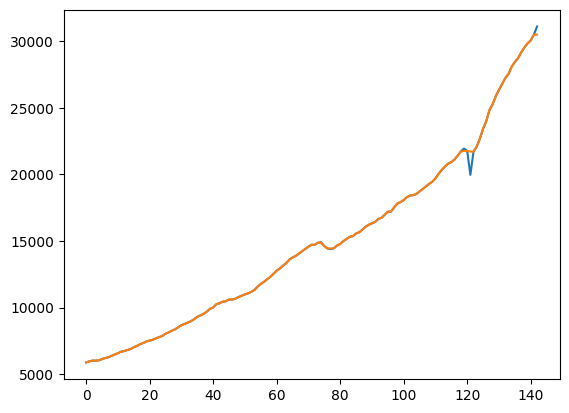

In [118]:
filtered = medfilt(df_quarterly['gdp'].values, kernel_size=3)
plt.plot(df_quarterly['gdp'].values)
plt.plot(filtered)

In [162]:
df_ml = df_diff.copy()
# df_ml['gdp_growth'] = medfilt(df_diff['gdp_growth'].values, kernel_size=5)
# df_ml['cpi_inflation'] = medfilt(df_diff['cpi_inflation'].values, kernel_size=5)
# df_ml['unrate_diff'] = medfilt(df_diff['unrate_diff'].values, kernel_size=5)

# TODO 3.1: Сформируйте целевую переменную (Direct Forecasting).
# Нам нужно предсказать рост ВВП через год (4 квартала). 
# Используйте сдвиг ряда назад во времени (метод .shift с отрицательным значением).
df_ml['target_gdp_4q'] = df_ml['gdp_growth'].shift(-4)

# TODO 3.2: Сгенерируйте лаговые признаки.
# Создайте циклом лаги (t-1 и t-2) для всех предикторов из списка feature_cols.
feature_cols =['gdp_growth', 'cpi_inflation', 'unrate_diff']

for col in feature_cols:
    df_ml[f'{col}_lag1'] = df_ml[col].shift(1)
    df_ml[f'{col}_lag2'] = df_ml[col].shift(2)

# TODO 3.3: Добавьте оконную статистику (Rolling Window).
# Рассчитайте скользящее стандартное отклонение роста ВВП за последние 4 квартала (волатильность).
df_ml['gdp_volatility_4q'] = df_ml['gdp_growth'].rolling(window=4).std()

df_ml.dropna(inplace=True)

# TODO 3.4: Разделите выборку на Train и Test без перемешивания (Data Leakage prevention).
# Обучающая выборка: строго до 1 января 2019 года.
# Тестовая выборка: начиная с 1 января 2019 года включительно.
train = df_ml[df_ml.index < '2016-01-01']
test = df_ml[df_ml.index >= '2016-01-01']

X_cols =[c for c in df_ml.columns if 'target' not in c]

X_train, y_train = train[X_cols], train['target_gdp_4q']
X_test, y_test = test[X_cols], test['target_gdp_4q']


In [163]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO 4.1: Инициализируйте RandomForestRegressor. 
# Задайте количество деревьев = 100, максимальную глубину = 5 и зафиксируйте random_state.
rf_model = RandomForestRegressor(n_estimators=1000, max_depth=3)

# TODO 4.2: Обучите модель на тренировочных данных и сделайте прогноз на тестовых.
# <ВАШ_КОД: Обучение>
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# TODO 4.3: Инициализируйте GradientBoostingRegressor.
# Параметры: 100 деревьев, скорость обучения (learning_rate) = 0.05, глубина = 3.
gb_model = GradientBoostingRegressor(max_depth=2, learning_rate=0.05)

# TODO 4.4: Обучите модель градиентного бустинга и сделайте прогноз.
# <ВАШ_КОД: Обучение>
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)


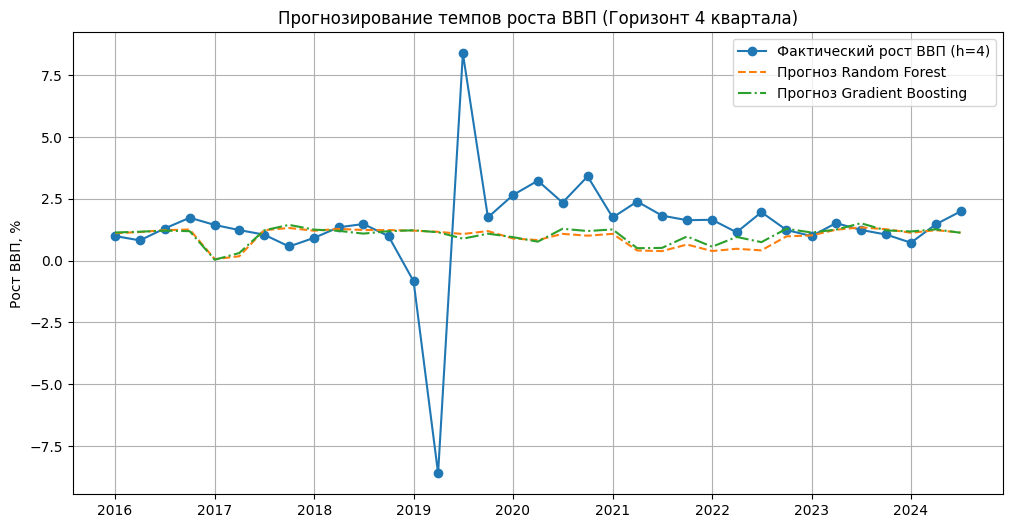

In [164]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

models_predictions = {
    'Random Forest': rf_preds,
    'Gradient Boosting': gb_preds
}

# # TODO 5.1: В цикле рассчитайте метрики качества (RMSE и MAE) для прогнозов.
# # Выведите результаты на экран. Помните, что RMSE - это корень из mean_squared_error.
# for name, preds in models_predictions.items():
#     rmse = # <ВАШ_КОД>
#     mae = # <ВАШ_КОД>
#     print(f"[{name}] RMSE: {rmse:.4f} | MAE: {mae:.4f}")

# # TODO 5.2: Извлеките важность признаков (Feature Importances) из обученной модели RandomForest.
# # Передайте массив важностей в pd.Series, используя X_cols в качестве индекса.
# importances_array = # <ВАШ_КОД: атрибут важности из rf_model>
# feature_importances = pd.Series(importances_array, index=X_cols)

# Визуализация (оставьте как есть для экономии времени на уроке)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Фактический рост ВВП (h=4)', marker='o')
plt.plot(y_test.index, rf_preds, label='Прогноз Random Forest', linestyle='--')
plt.plot(y_test.index, gb_preds, label='Прогноз Gradient Boosting', linestyle='-.')
plt.title('Прогнозирование темпов роста ВВП (Горизонт 4 квартала)')
plt.ylabel('Рост ВВП, %')
plt.grid(True)
plt.legend()
plt.show()

# feature_importances.nlargest(10).sort_values().plot(kind='barh', figsize=(10, 5))
# plt.title('Топ-10 значимых предикторов (Random Forest)')
# plt.xlabel('Относительная важность')
# plt.show()


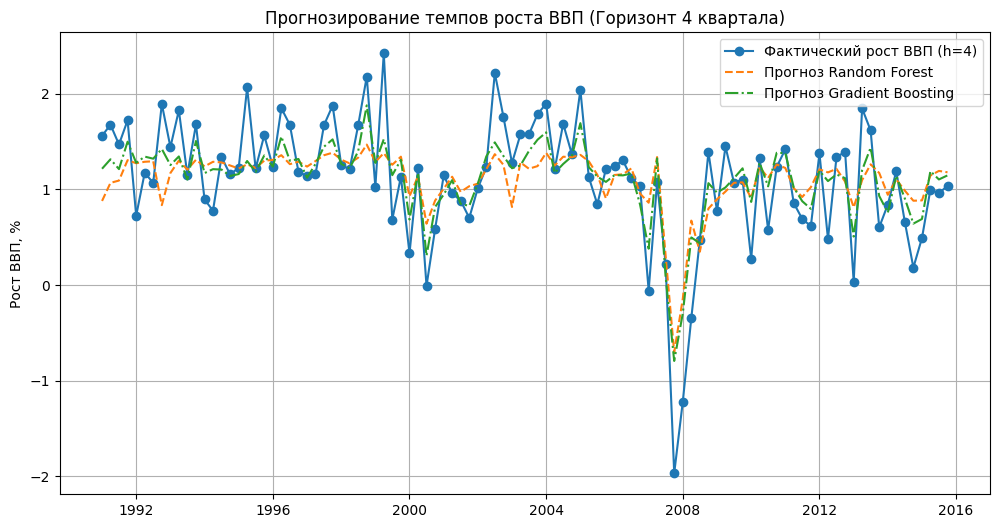

In [165]:
rf_preds_train = rf_model.predict(X_train)
gb_preds_train = gb_model.predict(X_train)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Фактический рост ВВП (h=4)', marker='o')
plt.plot(y_train.index, rf_preds_train, label='Прогноз Random Forest', linestyle='--')
plt.plot(y_train.index, gb_preds_train, label='Прогноз Gradient Boosting', linestyle='-.')
plt.title('Прогнозирование темпов роста ВВП (Горизонт 4 квартала)')
plt.ylabel('Рост ВВП, %')
plt.grid(True)
plt.legend()
plt.show()

In [227]:
df_ml = df_quarterly.copy()
# df_ml['gdp_growth'] = medfilt(df_diff['gdp_growth'].values, kernel_size=5)
# df_ml['cpi_inflation'] = medfilt(df_diff['cpi_inflation'].values, kernel_size=5)
# df_ml['unrate_diff'] = medfilt(df_diff['unrate_diff'].values, kernel_size=5)

# TODO 3.1: Сформируйте целевую переменную (Direct Forecasting).
# Нам нужно предсказать рост ВВП через год (4 квартала). 
# Используйте сдвиг ряда назад во времени (метод .shift с отрицательным значением).
df_ml['target_gdp_4q'] = df_ml['gdp'].shift(-4)

# TODO 3.2: Сгенерируйте лаговые признаки.
# Создайте циклом лаги (t-1 и t-2) для всех предикторов из списка feature_cols.
feature_cols =['gdp', 'cpi', 'unrate']

for col in feature_cols:
    df_ml[f'{col}_lag1'] = df_ml[col].shift(1)
    df_ml[f'{col}_lag2'] = df_ml[col].shift(2)
    df_ml[f'{col}_lag3'] = df_ml[col].shift(3)
    df_ml[f'{col}_lag4'] = df_ml[col].shift(4)

# TODO 3.3: Добавьте оконную статистику (Rolling Window).
# Рассчитайте скользящее стандартное отклонение роста ВВП за последние 4 квартала (волатильность).
df_ml['gdp_volatility_4q'] = df_ml['gdp'].rolling(window=4).std()

df_ml.dropna(inplace=True)

# TODO 3.4: Разделите выборку на Train и Test без перемешивания (Data Leakage prevention).
# Обучающая выборка: строго до 1 января 2019 года.
# Тестовая выборка: начиная с 1 января 2019 года включительно.
train = df_ml[df_ml.index < '2016-01-01']
test = df_ml[df_ml.index >= '2016-01-01']

# scaler = StandardScaler()
# train = scaler.fit_transform(train)
# test = scaler.fit_transform(test)

X_cols =[c for c in df_ml.columns if 'target' not in c]

X_train, y_train = train[X_cols], train['target_gdp_4q']
X_test, y_test = test[X_cols], test['target_gdp_4q']


In [228]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
y_train = y_train-y_train.mean()
y_train = y_train / y_train.abs().max()
y_test = y_test-y_test.mean()
y_test = y_test / y_test.abs().max()


In [229]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO 4.1: Инициализируйте RandomForestRegressor. 
# Задайте количество деревьев = 100, максимальную глубину = 5 и зафиксируйте random_state.
rf_model = RandomForestRegressor(n_estimators=1000, max_depth=3)

# TODO 4.2: Обучите модель на тренировочных данных и сделайте прогноз на тестовых.
# <ВАШ_КОД: Обучение>
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# TODO 4.3: Инициализируйте GradientBoostingRegressor.
# Параметры: 100 деревьев, скорость обучения (learning_rate) = 0.05, глубина = 3.
gb_model = GradientBoostingRegressor(max_depth=2, learning_rate=0.05)

# TODO 4.4: Обучите модель градиентного бустинга и сделайте прогноз.
# <ВАШ_КОД: Обучение>
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)


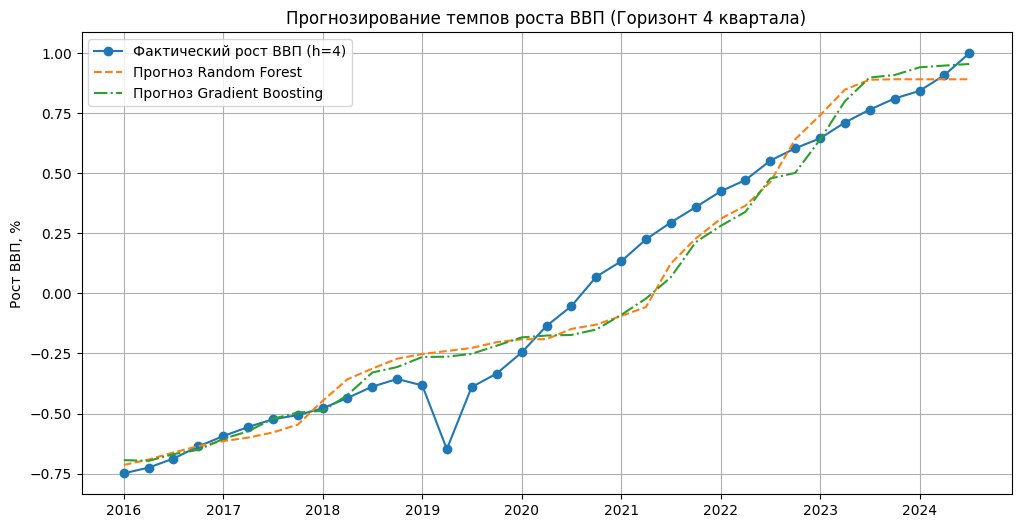

In [231]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

models_predictions = {
    'Random Forest': rf_preds,
    'Gradient Boosting': gb_preds
}

# # TODO 5.1: В цикле рассчитайте метрики качества (RMSE и MAE) для прогнозов.
# # Выведите результаты на экран. Помните, что RMSE - это корень из mean_squared_error.
# for name, preds in models_predictions.items():
#     rmse = # <ВАШ_КОД>
#     mae = # <ВАШ_КОД>
#     print(f"[{name}] RMSE: {rmse:.4f} | MAE: {mae:.4f}")

# # TODO 5.2: Извлеките важность признаков (Feature Importances) из обученной модели RandomForest.
# # Передайте массив важностей в pd.Series, используя X_cols в качестве индекса.
# importances_array = # <ВАШ_КОД: атрибут важности из rf_model>
# feature_importances = pd.Series(importances_array, index=X_cols)

# Визуализация (оставьте как есть для экономии времени на уроке)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Фактический рост ВВП (h=4)', marker='o')
plt.plot(y_test.index, rf_preds, label='Прогноз Random Forest', linestyle='--')
plt.plot(y_test.index, gb_preds, label='Прогноз Gradient Boosting', linestyle='-.')
shift = 2
# plt.plot(y_test[:-shift].index, rf_preds[shift:], label='Прогноз Random Forest', linestyle='--')
# plt.plot(y_test[:-shift].index, gb_preds[shift:], label='Прогноз Gradient Boosting', linestyle='-.')
plt.title('Прогнозирование темпов роста ВВП (Горизонт 4 квартала)')
plt.ylabel('Рост ВВП, %')
plt.grid(True)
plt.legend()
plt.show()

# feature_importances.nlargest(10).sort_values().plot(kind='barh', figsize=(10, 5))
# plt.title('Топ-10 значимых предикторов (Random Forest)')
# plt.xlabel('Относительная важность')
# plt.show()


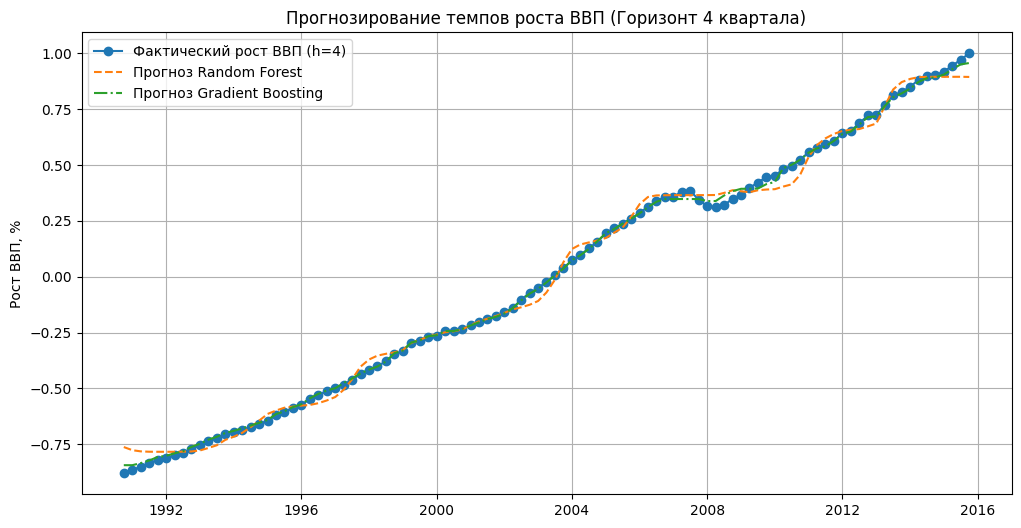

In [193]:
rf_preds_train = rf_model.predict(X_train)
gb_preds_train = gb_model.predict(X_train)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Фактический рост ВВП (h=4)', marker='o')
plt.plot(y_train.index, rf_preds_train, label='Прогноз Random Forest', linestyle='--')
plt.plot(y_train.index, gb_preds_train, label='Прогноз Gradient Boosting', linestyle='-.')
plt.title('Прогнозирование темпов роста ВВП (Горизонт 4 квартала)')
plt.ylabel('Рост ВВП, %')
plt.grid(True)
plt.legend()
plt.show()

Index(['gdp', 'cpi', 'unrate'], dtype='object')


/opt/homebrew/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


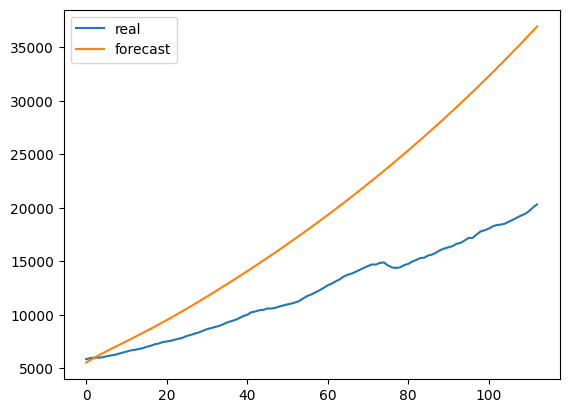

In [226]:
df_diff_filt = df_quarterly.copy()

df_diff_train = df_diff_filt.iloc[:int(len(df_quarterly)*0.8)-1]
df_diff_test = df_diff_filt.iloc[int(len(df_quarterly)*0.8):]
print(df_diff_train.columns)
# scaler = StandardScaler()
# df_diff_train = scaler.fit_transform(df_diff_train)
# df_diff_test = scaler.fit_transform(df_diff_test)


model_var = VAR(df_diff_train)
results_var = model_var.fit(ic='aic')
res = results_var.forecast(df_diff_train[results_var.k_ar:].values, len(df_diff_train))
plt.plot(df_diff_train['gdp'].values, label='real')
plt.plot(res.T[0]-15000, label='forecast')
plt.legend()

In [207]:
df_diff_test[0]

array([-1.28371057, -1.29655598, -0.40633115])